# Computer Lab 4: Modeling El Niño-Southern Oscillation
This notebook will contain the entirety of the El Niño-Southern Oscillation computer lab.

## Setup
For this assignment, we will need `matplotlib.pyplot`, `numpy`, and `scipy.integrate`, as per usual. We will also need `sympy` again.

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
import sympy

## Section 1: Equilibrium Solutions to the ENSO Model
We begin by looking at equilibrium solutions, as detailed in class.

### Part 1.1
Here, we are asked to seek steady-state solutions to the Vallis ENSO model. Recall that this model, in its simplest form, gives us three equations governing the zonal dynamics of the Pacific as

$$ \frac{d}{dt}U = B(T_e-T_w) + C(U_0-U) $$
$$ \frac{d}{dt}T_e = \frac{U}{\Delta x}T_w + A(T_0-T_e) $$
$$ \frac{d}{dt}T_w = \frac{-U}{\Delta x}T_e + A(T_0-T_w) $$

To find our steady-state solution, we set all of these derivatives equal to zero, and solve. Let's begin with the case where $U_0=-0.5\mathrm{ms}^{-1}$ and $B=1.3\times10^{-7}\mathrm{ms}^{-2}\degree\mathrm{C}^{-1}$. We are also given that $\Delta x = 7500\mathrm{km} = 7.5\times10^6\mathrm{m}$, $T_0=-15\degree\mathrm{C}$, $A = (6\;\mathrm{months})^{-1}$, and $C=(2\;\mathrm{months})^{-1}$. Let's quickly convert $A$ and $C$ to seconds by finding the average number of seconds in a month.

In [37]:
# Year = 365.2425 days x 24 hours x 60 minutes x 60 seconds
sec_year = 365.2425 * 24 * 60 * 60
A = 1 / (6 / 12 * sec_year)
C = 1 / (2 / 12 * sec_year)
print(A, C)

6.337747701362287e-08 1.9013243104086862e-07


We find that $A=6.338\times10^{-8}\mathrm{s}^{-1}$ and $C=1.901\times10^{-7}\mathrm{s}^{-1}$. With that, let's set up our first case and solve.

In [158]:
del_x = 7.5 * 10**6
T_0 = 15
U_0 = -0.5
B = 1.3 * 10**(-7)

T_e, T_w, U = sympy.symbols("T_e T_w U")

eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

slns = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])

In [57]:
num = 1
for T_e_sln, T_w_sln, U_sln in slns:
    print("Sln. #" + str(num) + "\n",
    "U = " + str(round(U_sln, 4)) + " m/s\n",
    "T_e = " + str(round(T_e_sln, 4)) + " degC\n",
    "T_w = " + str(round(T_w_sln, 4)) + " degC\n",
    "Resid. for eq1, eq2, eq3: ",
    round(B * (T_e_sln - T_w_sln) + C * (U_0 - U_sln), 4), 
    round(U_sln / del_x * T_w_sln + A * (T_0 - T_e_sln), 4), 
    round(-1 * U_sln / del_x * T_e_sln + A * (T_0 - T_w_sln), 4))
    num += 1


Sln. #1
 U = -3.3517 m/s
 T_e = -1.7896 degC
 T_w = 2.3811 degC
 Resid. for eq1, eq2, eq3:  0.0 0.0 0.0
Sln. #2
 U = 2.8398 m/s
 T_e = 2.8511 degC
 T_w = -2.0335 degC
 Resid. for eq1, eq2, eq3:  0.0 0.0 0.0
Sln. #3
 U = 0.0119 m/s
 T_e = 15.3650 degC
 T_w = 14.6163 degC
 Resid. for eq1, eq2, eq3:  0 0.0 0.0


We find three real solutions, and for each solution, we have reached equilibrium with Vallis' state equations. This means our next step is to repeat this process for the next two cases, now allowing $B$ to vary.

In [ ]:
# Define new variables
B_range = np.linspace(10**(-9), 10**(-6))
U_0 = 0

# Loop through possible values of B
T_diff = np.array([0, 0])
for B in B_range:

    # Set up equations
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])
    slns = np.array([(T_e_sln, T_w_sln, U_sln) for T_e_sln, T_w_sln, U_sln in solved])

    # Determine which solutions are real and filter
    real_sln = np.array([all([T_e_sln.is_real, T_w_sln.is_real, U_sln.is_real]) for T_e_sln, T_w_sln, U_sln in solved])
    num_real_sln = int(slns[real_sln].size / 3)

    # Collect temperature differences
    for sln in slns[real_sln]:
        
        #                                         T_w   -  T_e
        T_diff = np.vstack([T_diff, np.array([B, sln[1] - sln[0]])])

# Delete first row (it was a filler row)
T_diff = np.delete(T_diff, (0), axis = 0)

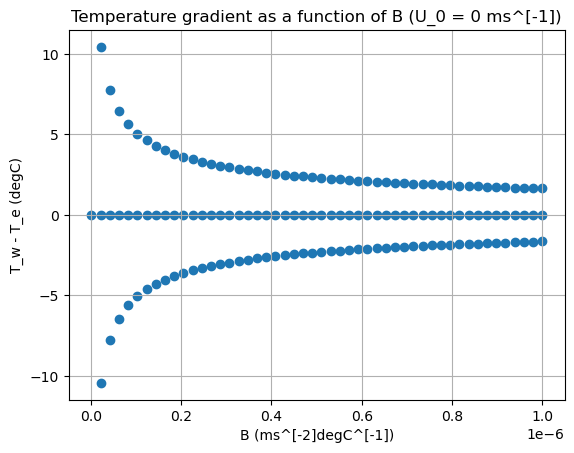

In [149]:
# Set up plot
fig, ax = plt.subplots()

# Plot data and label
ax.scatter(T_diff[:,0], T_diff[:,1])
ax.set_title("Temperature gradient as a function of B (U_0 = 0 ms^[-1])")
ax.set_ylabel("T_w - T_e (degC)")
ax.set_xlabel("B (ms^[-2]degC^[-1])")
ax.grid()

As $B$ increases, we see that one of the solutions stays consistently at a $0\degree\mathrm{C}$ temperature gradient, and the other two --- symmetrically around the $0\degree\mathrm{C}$-axis --- approach the midpoint from what seem to be $+\infty$ and $-\infty$. Let's do the same analysis with $U_0=-0.5\mathrm{ms}^{-1}$.

In [ ]:
# Define new variables
U_0 = -0.5

# Loop through possible values of B
T_diff = np.array([0, 0])
for B in B_range:

    # Set up equations
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])
    slns = np.array([(T_e_sln, T_w_sln, U_sln) for T_e_sln, T_w_sln, U_sln in solved])

    # Determine which solutions are real and filter
    real_sln = np.array([all([T_e_sln.is_real, T_w_sln.is_real, U_sln.is_real]) for T_e_sln, T_w_sln, U_sln in solved])
    num_real_sln = int(slns[real_sln].size / 3)

    # Collect temperature differences
    for sln in slns[real_sln]:
        
        #                                         T_w   -  T_e
        T_diff = np.vstack([T_diff, np.array([B, sln[1] - sln[0]])])

# Delete first row (it was a filler row)
T_diff = np.delete(T_diff, (0), axis = 0)

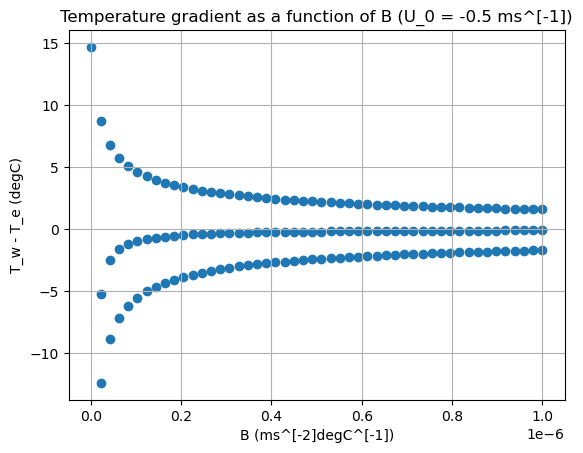

In [155]:
# Set up plot
fig, ax = plt.subplots()

# Plot data and label
ax.scatter(T_diff[:,0], T_diff[:,1])
ax.set_title("Temperature gradient as a function of B (U_0 = -0.5 ms^[-1])")
ax.set_ylabel("T_w - T_e (degC)")
ax.set_xlabel("B (ms^[-2]degC^[-1])")
ax.grid()

This case seems very similar to the prior, except now the "middle solution" also approaches $0\degree\mathrm{C}$ from $-\infty$. This makes sense; slight differences in initial conditions may change the behavior of our system dramatically in some regimes, but the asymptotic temperature gradient as $B$ increases seems to remain relatively invariant under the conditions we've tested.

### Part 1.2
Now, we want to find the stability of each of our solutions. In class, we discussed how the eigenvalues of our linearized matrix $\mathbf{E}$ will determine the stability of our system. As a refresher,

$$ \mathbf{E} = \begin{bmatrix}
                    -C & B & -B \\
                    \frac{T_w^*}{\Delta x} & -A & \frac{U^*}{\Delta x} \\
                    \frac{T_e^*}{\Delta x} & \frac{U^*}{\Delta x} & -A
                \end{bmatrix} $$

Let's start with the first case, where $U_0=-0.5\mathrm{ms}^{-1}$ and $B=1.3\times10^{-7}\mathrm{ms}^{-2}\degree\mathrm{C}^{-1}$.

In [ ]:
B = 1.3 * 10**(-7)

T_e, T_w, U = sympy.symbols("T_e T_w U")

eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

slns = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])

num = 1
for T_e_sln, T_w_sln, U_sln in slns:

    # Calculate E
    E = np.array([[-C, B, -B],
                   [T_w_sln / del_x, -A, U_sln / del_x],
                   [T_e_sln / del_x, U_sln / del_x, -A]], dtype = float)
    
    # Find eigenvalues
    eigs = np.real(np.linalg.eig(E)[0])
    if any(eigs > 0):
        stability = "unstable"
    else:
        stability = "stable"
    
    # Print diagnostics
    print("Sln. #" + str(num) + "\n",
    "U = " + str(round(U_sln, 4)) + " m/s\n",
    "T_e = " + str(round(T_e_sln, 4)) + " degC\n",
    "T_w = " + str(round(T_w_sln, 4)) + " degC\n",
    "Eigenvalues = ", eigs,
    "\nStability = " + stability)
    num += 1

Sln. #1
 U = -3.3517 m/s
 T_e = -1.7896 degC
 T_w = 2.3811 degC
 Eigenvalues =  [ 4.89828244e-07 -2.96450769e-07 -5.10264860e-07] 
Stability = unstable
Sln. #2
 U = 2.8398 m/s
 T_e = 2.8511 degC
 T_w = -2.0335 degC
 Eigenvalues =  [-3.16074039e-07 -3.16074039e-07  3.15260694e-07] 
Stability = unstable
Sln. #3
 U = 0.0119 m/s
 T_e = 15.3650 degC
 T_w = 14.6163 degC
 Eigenvalues =  [-1.27546227e-07 -1.27546227e-07 -6.17949317e-08] 
Stability = stable


Here, we find that when $U=0.0119\mathrm{ms}^{-1}$, $T_e=15.365\degree\mathrm{C}$, and $T_w=14.6163\degree\mathrm{C}$, our system is stable; the other two solutions are not. Let's repeat this process for varying $B$ in the first case, where $U_0 = 0$.

In [205]:
# Set initial values
B_range_small = np.linspace(10**(-9), 10**(-6), 10)
U_0 = 0

# Iterate
for B in B_range_small:
    
    # Set up equation
    T_e, T_w, U = sympy.symbols("T_e T_w U")
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])
    slns = np.array([(T_e_sln, T_w_sln, U_sln) for T_e_sln, T_w_sln, U_sln in solved])

    # Determine which solutions are real, filter
    real_sln = np.array([all([T_e_sln.is_real, T_w_sln.is_real, U_sln.is_real]) for T_e_sln, T_w_sln, U_sln in solved])
    real_slns = slns[real_sln]

    # Check all solutions
    num = 1
    print("For B = " + str(B))
    for sln in real_slns:

        # Isolate solutions
        T_e_sln, T_w_sln, U_sln = sln
        
        # Calculate E
        E = np.array([[-C, B, -B],
                    [T_w_sln / del_x, -A, U_sln / del_x],
                    [T_e_sln / del_x, U_sln / del_x, -A]], dtype = float)
        
        # Find eigenvalues
        eigs = np.real(np.linalg.eig(E)[0])
        if any(eigs > 0):
            stability = "unstable"
        else:
            stability = "stable"
        
        # Print diagnostics
        print("Temp. gradient = " + str(round(T_w_sln - T_e_sln, 2)) + ": " + stability, end = "   ")
        num += 1
    print("\n---------------------------")


For B = 1e-09
Temp. gradient = 0: stable   
---------------------------
For B = 1.1199999999999998e-07
Temp. gradient = 4.85: unstable   Temp. gradient = -4.85: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 2.2299999999999997e-07
Temp. gradient = 3.46: unstable   Temp. gradient = -3.46: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 3.34e-07
Temp. gradient = 2.84: unstable   Temp. gradient = -2.84: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 4.45e-07
Temp. gradient = 2.46: unstable   Temp. gradient = -2.46: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 5.56e-07
Temp. gradient = 2.20: unstable   Temp. gradient = -2.20: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 6.669999999999999e-07
Temp. gradient = 2.01: unstable   Temp. gradient = -2.01: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 7.7799999999999

It is clearly evident from the results above that for each of the non-zero values of $T_w-T_e$, the system is unstable for $U_0=0\mathrm{ms}^{-1}$. However, when this gradient is $0\degree\mathrm{C}$, the system is stable. This correlates with the middle solution on the plot. Let's look at the other possibility, $U_0=-0.5\degree\mathrm{C}$.

In [206]:
# Set initial values
U_0 = -0.5

# Iterate
for B in B_range_small:
    
    # Set up equation
    T_e, T_w, U = sympy.symbols("T_e T_w U")
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])
    slns = np.array([(T_e_sln, T_w_sln, U_sln) for T_e_sln, T_w_sln, U_sln in solved])

    # Determine which solutions are real, filter
    real_sln = np.array([all([T_e_sln.is_real, T_w_sln.is_real, U_sln.is_real]) for T_e_sln, T_w_sln, U_sln in solved])
    real_slns = slns[real_sln]

    # Check all solutions
    num = 1
    print("For B = " + str(B))
    for sln in real_slns:

        # Isolate solutions
        T_e_sln, T_w_sln, U_sln = sln
        
        # Calculate E
        E = np.array([[-C, B, -B],
                    [T_w_sln / del_x, -A, U_sln / del_x],
                    [T_e_sln / del_x, U_sln / del_x, -A]], dtype = float)
        
        # Find eigenvalues
        eigs = np.real(np.linalg.eig(E)[0])
        if any(eigs > 0):
            stability = "unstable"
        else:
            stability = "stable"
        
        # Print diagnostics
        print("Temp. gradient = " + str(round(T_w_sln - T_e_sln, 2)) + ": " + stability, end = "   ")
        num += 1
    print("\n---------------------------")


For B = 1e-09
Temp. gradient = 14.72: unstable   
---------------------------
For B = 1.1199999999999998e-07
Temp. gradient = 4.46: unstable   Temp. gradient = -5.28: unstable   Temp. gradient = -0.87: stable   
---------------------------
For B = 2.2299999999999997e-07
Temp. gradient = 3.26: unstable   Temp. gradient = -3.68: unstable   Temp. gradient = -0.43: stable   
---------------------------
For B = 3.34e-07
Temp. gradient = 2.70: unstable   Temp. gradient = -2.98: unstable   Temp. gradient = -0.29: stable   
---------------------------
For B = 4.45e-07
Temp. gradient = 2.36: unstable   Temp. gradient = -2.57: unstable   Temp. gradient = -0.22: stable   
---------------------------
For B = 5.56e-07
Temp. gradient = 2.12: unstable   Temp. gradient = -2.29: unstable   Temp. gradient = -0.17: stable   
---------------------------
For B = 6.669999999999999e-07
Temp. gradient = 1.94: unstable   Temp. gradient = -2.08: unstable   Temp. gradient = -0.14: stable   
---------------------

Our "middle solution" is still stable, with the positive- and negative-tending solutions remaining unstable. This is interesting --- even with the asymptotic behavior of the normal solution as $B$ gets very small, the solution remains stable. However, this is consistent with the first and second cases, and still represents the system with the smallest zonal climate variability. 

## Section 2: Time-varying Solutions
Now, we shift our focus to time-varying solutions. This section only has one "task", but it involves looking at several possible values to experiment with. For each set of values, we will also choose to look at the cases in which the temperature gradient is positive, negative, or zero. Let's begin directly with the first one.

### Case 1
$\mathit{U_0=-0.5ms^{-1}}$, $\mathit{B=1.3\times10^{-7}ms^{-2}\degree C^{-1}}$

Most of the rest of this section will be similar to this code, but let's take a second to understand how we will tackle this first task. We will employ `scipy.integrate`'s `odeint()` to integrate our system of ODEs with the initial conditions we choose for $T_e$ and $T_w$. We will run each simulation for ten years, then plot, then repeat for other selections of initial conditions. We will repeat this four times per set of values to understand the system's behavior under a wide range of physically realistic conditions, modeled as

$$ (T_{e,0}, T_{w,0})\in\{(15\degree\mathrm{C}, 15\degree\mathrm{C}), (-15\degree\mathrm{C}, -15\degree\mathrm{C}), (15\degree\mathrm{C}, 0\degree\mathrm{C}), (0\degree\mathrm{C}, 15\degree\mathrm{C}), (0\degree\mathrm{C}, 0\degree\mathrm{C})\} $$

<p style="color:red">TODO DECIDE HOW MANY CASES PER SET OF VALUES</p>

In [277]:
# Ensure our values are well-defined
del_x = 7.5 * 10**6
T_0 = 15
A = 1 / (6 / 12 * sec_year)
C = 1 / (2 / 12 * sec_year)
ten_year = np.linspace(0, sec_year * 10, 100)
sec_year = 365.2425 * 24 * 60 * 60

# Vary values
U_0 = -0.5
B = 1.3 * 10**(-7)

def system_eq(y, t):
    U = y[0]; T_e = y[1]; T_w = y[2]
    eq_1 = B * (T_e - T_w) + C * (U_0 - U)
    eq_2 = U / del_x * T_w + A * (T_0 - T_e)
    eq_3 = -U / del_x * T_e + A * (T_0 - T_w)

    return np.array([eq_1, eq_2, eq_3])

T_e_0 = 15
T_w_0 = 15
sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
temp_grad = sln[:,2] - sln[:,1]
U_vary = sln[:,0]

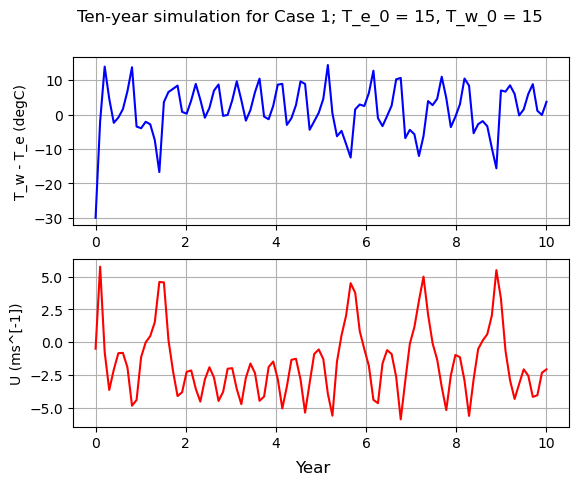

In [276]:
# Set up plot
fig, axs = plt.subplots(2, 1)

# Plot data
axs[0].plot(ten_year / sec_year, temp_grad, color = "blue", label = "Temperature gradient")
axs[1].plot(ten_year / sec_year, U_vary, color = "red", label = "Surface current speed")

# Label figure
fig.suptitle("Ten-year simulation for Case 1; T_e_0 = 15, T_w_0 = 15 ")
fig.supxlabel("Year")

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line
